# ALS × MLS — Future Research Direction (Test LiMatch)

Pipeline :
1. **Crop** chaque bloc ALS sur la zone d'intérêt (bbox LV95)
2. **Merge** les crops ALS et les merge en un seul nuage
3. **LiMatch** successif : nuage ALS mergé ↔ chaque ligne MLS

Pas de vecteurs laser (ALS n'en a pas)

In [66]:
# ==============================================================
# CELL 1 — CONFIG
# ==============================================================
import numpy as np
import laspy
import pandas as pd
from pathlib import Path
import sys

sys.path.insert(0, "/home/b085164/PDM_Romain_Defferrard/ESO-PDM")
from navtools_PDM.pipeline import run_limatch_api, get_repo_root

# ── Blocs ALS (plusieurs fichiers LAS/LAZ) ────────────────────
ALS_BLOCKS = [
    Path("/media/b085164/LaCie/2026spring_RD/ECCR/ALS-MLS/blocs/bloc1.laz"),
    Path("/media/b085164/LaCie/2026spring_RD/ECCR/ALS-MLS/blocs/bloc2.laz"),
    Path("/media/b085164/LaCie/2026spring_RD/ECCR/ALS-MLS/blocs/bloc3.laz"),
]

# ── Zone de crop ALS — bbox LV95 (E_min, E_max, N_min, N_max) ─
CROP_BBOX = (
    2533226.8,   # E_min
    2533314.5,   # E_max
    1154996.5,   # N_min
    1155156.9,   # N_max
)

# ── Lignes MLS (une par fichier LAS) ─────────────────────────
MLS_LINES = [
    Path("/media/b085164/LaCie/2026spring_RD/ECCR/ALS-MLS/outage_2/merged/HA_LR/merged_1000_HA_LR.las"),
    Path("/media/b085164/LaCie/2026spring_RD/ECCR/ALS-MLS/outage_2/merged/HA_LR/merged_2000_HA_LR.las"),
]

# ── Config LiMatch ────────────────────────────────────────────
LIMATCH_CFG = "/home/b085164/PDM_Romain_Defferrard/ESO-PDM/Patcher/submodules/limatch/configs/MLS-ALS.yml"

# ── Dossier de sortie ─────────────────────────────────────────
OUT_BASE = Path("/media/b085164/LaCie/2026spring_RD/ECCR/ALS-MLS/limatch_outage_2_rsc_0.2")
OUT_BASE.mkdir(parents=True, exist_ok=True)

# ── Décimation ALS pour alléger (1 = pas de décimation) ──────
ALS_DECIMATE = 1


crop_dir = Path("/media/b085164/LaCie/2026spring_RD/ECCR/ALS-MLS/crops")

print(f"{len(ALS_BLOCKS)} blocs ALS")
print(f"{len(MLS_LINES)} lignes MLS")
print(f"Bbox crop : E=[{CROP_BBOX[0]:.0f}, {CROP_BBOX[1]:.0f}]  N=[{CROP_BBOX[2]:.0f}, {CROP_BBOX[3]:.0f}]")
print(f"Out : {OUT_BASE}")

3 blocs ALS
2 lignes MLS
Bbox crop : E=[2533227, 2533314]  N=[1154996, 1155157]
Out : /media/b085164/LaCie/2026spring_RD/ECCR/ALS-MLS/limatch_outage_2_rsc_0.2


In [69]:
ALS_MERGED_PATH = OUT_BASE / "als_crop_merged.las"

# ── Crop bloc par bloc ────────────────────────────────────────
crop_dir = Path("/media/b085164/LaCie/2026spring_RD/ECCR/ALS-MLS/crops")

if ALS_MERGED_PATH.exists():
    print(f"[SKIP] ALS mergé déjà existant : {ALS_MERGED_PATH.name}")
    # Reconstruire crop_parts depuis les fichiers déjà croppés
    crop_parts = sorted(crop_dir.glob("*_crop.las"))
    print(f"  {len(crop_parts)} crop(s) retrouvé(s) dans {crop_dir.name}/")
else:
    E_min, E_max, N_min, N_max = CROP_BBOX
    crop_dir.mkdir(exist_ok=True)
    crop_parts = []

    for block_path in ALS_BLOCKS:
        out_crop = crop_dir / f"{block_path.stem}_crop.las"
        if out_crop.exists():
            print(f"[SKIP] {block_path.name} → {out_crop.name}")
            crop_parts.append(out_crop)
            continue
        print(f"Lecture  : {block_path.name}")
        las  = laspy.read(block_path)
        x, y = np.asarray(las.x), np.asarray(las.y)
        mask = (x >= E_min) & (x <= E_max) & (y >= N_min) & (y <= N_max)
        if ALS_DECIMATE > 1:
            idx  = np.where(mask)[0][::ALS_DECIMATE]
            mask = np.zeros(len(x), dtype=bool)
            mask[idx] = True
        n_kept = int(mask.sum())
        print(f"  {n_kept:,} pts dans la bbox", end=" ")
        if n_kept == 0:
            print("!! vide — bloc hors zone")
            continue
        las[mask].write(out_crop)
        print(f"→ {out_crop.name}")
        crop_parts.append(out_crop)

    if not crop_parts:
        raise RuntimeError("Aucun point ALS dans la bbox — vérifier CROP_BBOX et les chemins")

    # ── Merge ────────────────────────────────────────────────────
    print(f"\nMerge de {len(crop_parts)} cropS -> {ALS_MERGED_PATH.name}")
    all_las = [laspy.read(cp) for cp in crop_parts]
    for cp, las in zip(crop_parts, all_las):
        print(f"  {cp.name} : {len(las.x):,} pts")
    ref = all_las[0]
    X = np.concatenate([np.asarray(l.x) for l in all_las])
    Y = np.concatenate([np.asarray(l.y) for l in all_las])
    Z = np.concatenate([np.asarray(l.z) for l in all_las])
    hdr = laspy.LasHeader(point_format=ref.point_format, version=ref.header.version)
    hdr.offsets = np.array([X.min(), Y.min(), Z.min()])
    hdr.scales  = ref.header.scales
    out = laspy.LasData(header=hdr)
    out.x, out.y, out.z = X, Y, Z
    out.write(ALS_MERGED_PATH)
    print(f"ALS MERGED : {len(X):,} pts -> {ALS_MERGED_PATH.name}")


[SKIP] ALS mergé déjà existant : als_crop_merged.las
  3 crop(s) retrouvé(s) dans crops/


In [70]:
# ==============================================================
# CELL 3 — LANCER LIMATCH : ALS × chaque ligne MLS
# ==============================================================
# LiMatch est lancé avec :
#   cloud1 = ALS mergé  (reference)
#   cloud2 = ligne MLS  

repo_root      = get_repo_root()
limatch_results = []   # [(mls_label, corres_path)]

for mls_path in MLS_LINES:
    label  = mls_path.stem
    lm_dir = OUT_BASE / f"limatch_{label}"

    # Skip si déjà fait
    existing = list(lm_dir.rglob("corres_*.txt"))
    if existing:
        print(f"[SKIP] {label} — corres déjà existant : {existing[0].name}")
        limatch_results.append((label, existing[0]))
        continue

    print(f"\n{'='*55}")
    print(f"LiMatch  ALS  ↔  {label}")
    print(f"{'='*55}")

    run_limatch_api(
        repo_root=repo_root,
        limatch_cfg_path=LIMATCH_CFG,
        cloud1=ALS_MERGED_PATH,   # ALS = référence
        cloud2=mls_path,           # MLS = mobile
        out_dir=lm_dir,
    )

    corres_files = list(lm_dir.rglob("corres_*.txt"))
    if corres_files:
        limatch_results.append((label, corres_files[0]))
        print(f"  → {corres_files[0].name}")
    else:
        print(f"  !! Pas de corres_*.txt produit")

print(f"\n{len(limatch_results)}/{len(MLS_LINES)} lignes MLS avec correspondances.")

[SKIP] merged_1000_HA_LR — corres déjà existant : corres_als_crop_merged_merged_1000_HA_LR.txt
[SKIP] merged_2000_HA_LR — corres déjà existant : corres_als_crop_merged_merged_2000_HA_LR.txt

2/2 lignes MLS avec correspondances.


In [71]:
# ==============================================================
# CELL 4 — ANALYSE des correspondances
# ==============================================================
import matplotlib.pyplot as plt

def load_corres(path):
    """Charge corres_*.txt — header espaces, données virgules."""
    with open(path) as f:
        header_line = f.readline().strip()
    col_names = header_line.split()
    col_names = [c if not c.startswith('(') else 'comment' for c in col_names]
    df = pd.read_csv(path, sep=',', header=None, skiprows=1,
                     skipinitialspace=True, names=col_names)
    df = df.apply(pd.to_numeric, errors='coerce')
    print(f"  [load_corres] {path.name} → {df.shape[1]} cols, {len(df):,} lignes")
    return df

all_rows = []
for label, corres_path in limatch_results:
    df = load_corres(corres_path)
    d  = df['d_xyz'].dropna().values * 100
    print(f"  {label:40s}  N={len(d):6,}  "
          f"Q50={np.median(d):.2f} cm  "
          f"Q95={np.percentile(d,95):.2f} cm  "
          f"RMSE={np.sqrt(np.mean(d**2)):.2f} cm")
    df['d_cm'] = d
    all_rows.append((label, df))

# data_outage : dict scan_label → DataFrame (utilisé par cell 5)
data_outage = {label: df for label, df in all_rows}

  [load_corres] corres_als_crop_merged_merged_1000_HA_LR.txt → 17 cols, 815 lignes
  merged_1000_HA_LR                         N=   815  Q50=179.30 cm  Q95=196.33 cm  RMSE=179.17 cm
  [load_corres] corres_als_crop_merged_merged_2000_HA_LR.txt → 17 cols, 753 lignes
  merged_2000_HA_LR                         N=   753  Q50=152.60 cm  Q95=159.64 cm  RMSE=152.13 cm


In [73]:
# ==============================================================
# CELL 5 — REPROJECTION : validation du matching
# ==============================================================
# Pour chaque correspondance ALS↔MLS_outage :
#   1. Retrouver le même point physique dans MLS_nominal via time_b
#   2. Calculer dist(x_nom, x_ALS) = résidu si trajectoire nominale
#
# Double contrainte (pour gérer l'ambiguïté HA+LR même timestamp) :
#   - dt < 1e-4 s   (même mesure GPS)
#   - dist(x_nom, x_ALS) < 0.5 m  (même surface physique)
#
# Si dist(x_nom, x_ALS) ≈ baseline nominale (~5-6 cm)
# → LiMatch a trouvé les bons points malgré la dérive de 1.43 m

MLS_NOMINAL_PATHS = {
    'merged_1000_HA_LR': Path("/media/b085164/LaCie/2026spring_RD/ECCR/ALS-MLS/base/merged/HA_LR/merged_1000_HA_LR.las"),
    'merged_2000_HA_LR': Path("/media/b085164/LaCie/2026spring_RD/ECCR/ALS-MLS/base/merged/HA_LR/merged_2000_HA_LR.las"),
}

# Référence nominale (à ajuster selon tes résultats cell 4 nominal)
Q50_REF = {'merged_1000_HA_LR': 5.70, 'merged_2000_HA_LR': 5.40}

DT_MAX   = 1e-4   # tolérance timestamp GPS (s)
RALS_MAX = 0.50   # distance max x_nom ↔ x_ALS (m)
K        = 10     # candidats temporels à considérer


def reproject_to_nominal(corres_outage, nom_path, dt_max=1e-4, r_als_max=0.50, k=10):
    las     = laspy.read(nom_path)
    nom_t   = np.asarray(las.gps_time)
    nom_xyz = np.stack([np.asarray(las.x),
                        np.asarray(las.y),
                        np.asarray(las.z)], axis=1)
    print(f"  nominal : {len(nom_t):,} pts  t=[{nom_t.min():.3f}, {nom_t.max():.3f}]")

    sort_idx  = np.argsort(nom_t)
    nom_t_s   = nom_t[sort_idx]
    nom_xyz_s = nom_xyz[sort_idx]

    out_times = corres_outage['time_b'].values
    als_xyz   = corres_outage[['x_a', 'y_a', 'z_a']].values
    pos       = np.searchsorted(nom_t_s, out_times)

    res_xyz = np.full((len(out_times), 3), np.nan)
    valid   = np.zeros(len(out_times), dtype=bool)

    for i, (t, als) in enumerate(zip(out_times, als_xyz)):
        i0    = max(0, pos[i] - k//2)
        i1    = min(len(nom_t_s), pos[i] + k//2)
        cands = np.arange(i0, i1)
        dt_c  = np.abs(nom_t_s[cands] - t)
        ok    = dt_c < dt_max
        if not ok.any():
            continue
        cands_ok = cands[ok]
        d_als    = np.linalg.norm(nom_xyz_s[cands_ok] - als, axis=1)
        best     = np.argmin(d_als)
        if d_als[best] < r_als_max:
            res_xyz[i] = nom_xyz_s[cands_ok[best]]
            valid[i]   = True

    print(f"  {valid.sum()} appariements valides  |  {(~valid).sum()} exclus")

    df = corres_outage[valid].copy().reset_index(drop=True)
    nom = res_xyz[valid]
    df['x_nom'] = nom[:, 0]
    df['y_nom'] = nom[:, 1]
    df['z_nom'] = nom[:, 2]
    df['d_nominal_ALS'] = np.sqrt(
        (df['x_nom'] - df['x_a'])**2 +
        (df['y_nom'] - df['y_a'])**2 +
        (df['z_nom'] - df['z_a'])**2
    ) * 100   # cm
    df['d_outage_ALS'] = df['d_xyz'] * 100   # cm
    return df


reproj_results = {}
for label, nom_path in MLS_NOMINAL_PATHS.items():
    print(f"\n=== {label} ===")
    corres = data_outage[label]
    df_r   = reproject_to_nominal(corres, nom_path, DT_MAX, RALS_MAX, K)
    reproj_results[label] = df_r

    d_r = df_r['d_nominal_ALS'].values
    d_o = df_r['d_outage_ALS'].values
    print(f"  Résidu reprojeté  dist(x_nom, x_ALS) : "
          f"Q50={np.median(d_r):.2f} cm  Q95={np.percentile(d_r,95):.2f} cm")
    print(f"  Résidu outage obs dist(x_b,   x_ALS) : "
          f"Q50={np.median(d_o):.2f} cm  Q95={np.percentile(d_o,95):.2f} cm")
    print(f"  Référence nominale                   : "
          f"Q50={Q50_REF[label]:.2f} cm")


=== merged_1000_HA_LR ===
  nominal : 29,205,517 pts  t=[315690.000, 315717.153]
  814 appariements valides  |  1 exclus
  Résidu reprojeté  dist(x_nom, x_ALS) : Q50=8.83 cm  Q95=23.72 cm
  Résidu outage obs dist(x_b,   x_ALS) : Q50=179.30 cm  Q95=196.34 cm
  Référence nominale                   : Q50=5.70 cm

=== merged_2000_HA_LR ===
  nominal : 37,009,781 pts  t=[315733.765, 315767.000]
  753 appariements valides  |  0 exclus
  Résidu reprojeté  dist(x_nom, x_ALS) : Q50=8.50 cm  Q95=19.68 cm
  Résidu outage obs dist(x_b,   x_ALS) : Q50=152.60 cm  Q95=159.64 cm
  Référence nominale                   : Q50=5.40 cm


# Analyse L2L

Scenario      Scan         N    Q50 (cm)    Q95 (cm)
----------------------------------------------------
  nominal       1000       652        5.70       20.50
  nominal       2000       738        5.40       14.51
  outage        1000       815      179.30      196.33
  outage        2000       753      152.60      159.64


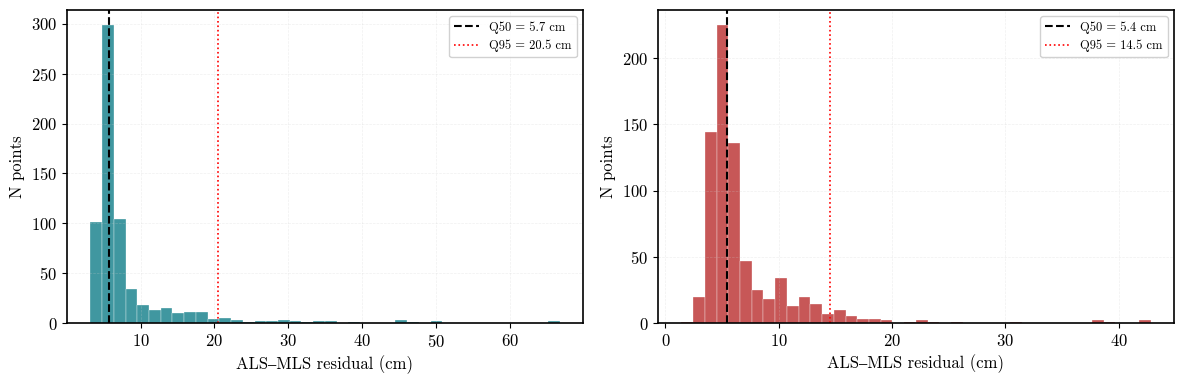

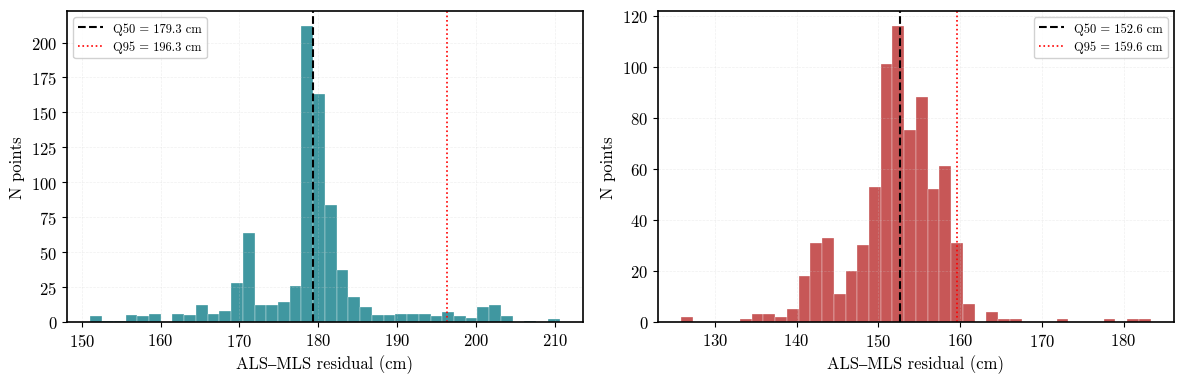

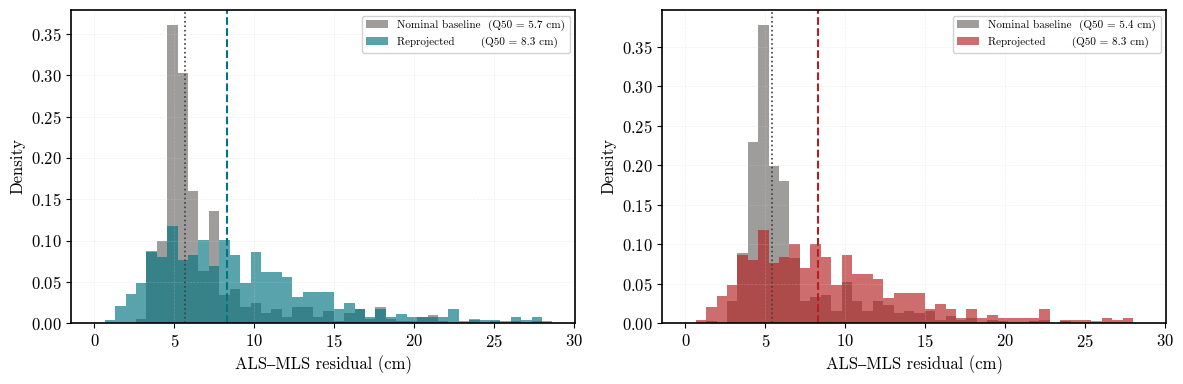


✓ 3 figures sauvegardées dans /media/b085164/LaCie/2026spring_RD/ECCR/ALS-MLS/limatch_outage_2_rsc_0.2/figures_rapport/


In [ ]:
# ==============================================================
# CELL 7 — FIGURES RAPPORT (version épurée)
# ==============================================================
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

FIG_DIR = OUT_BASE / "figures_rapport"
FIG_DIR.mkdir(exist_ok=True)

colors_scan = {'1000': '#007480', '2000': '#B51F1F'}

# ── Chargement des 3 scénarios ────────────────────────────────
CORRES_PATHS = {
    'nominal': {
        '1000': Path("/media/b085164/LaCie/2026spring_RD/ECCR/ALS-MLS/limatch_base_rsc_0.2/limatch_merged_1000_HA_LR/cor_outputs/corres_als_crop_merged_merged_1000_HA_LR.txt"),
        '2000': Path("/media/b085164/LaCie/2026spring_RD/ECCR/ALS-MLS/limatch_base_rsc_0.2/limatch_merged_2000_HA_LR/cor_outputs/corres_als_crop_merged_merged_2000_HA_LR.txt"),
    },
    'outage': {
        '1000': Path("/media/b085164/LaCie/2026spring_RD/ECCR/ALS-MLS/limatch_outage_2_rsc_0.2/limatch_merged_1000_HA_LR/cor_outputs/corres_als_crop_merged_merged_1000_HA_LR.txt"),
        '2000': Path("/media/b085164/LaCie/2026spring_RD/ECCR/ALS-MLS/limatch_outage_2_rsc_0.2/limatch_merged_2000_HA_LR/cor_outputs/corres_als_crop_merged_merged_2000_HA_LR.txt"),
    },
}

def load_corres(path):
    with open(path) as f:
        f.readline()
    df = pd.read_csv(path, sep=',', header=None, skiprows=1, skipinitialspace=True)
    cols = ['time_a','x_a','y_a','z_a','time_b','x_b','y_b','z_b',
            'd_xyz','icp_x','icp_y','icp_z']
    df.columns = cols[:df.shape[1]]
    df = df.apply(pd.to_numeric, errors='coerce').dropna(subset=['d_xyz'])
    df['d_cm'] = df['d_xyz'] * 100
    return df

data = {scen: {scan: load_corres(p) for scan, p in scans.items()}
        for scen, scans in CORRES_PATHS.items()}

# ── Résumé console ────────────────────────────────────────────
print(f"{'Scenario':12s}  {'Scan':6s}  {'N':>6}  {'Q50 (cm)':>10}  {'Q95 (cm)':>10}")
print("-" * 52)
for scen in ['nominal', 'outage']:
    for scan in ['1000', '2000']:
        d = data[scen][scan]['d_cm'].values
        print(f"  {scen:12s}  {scan:6s}  {len(d):>6,}  "
              f"{np.median(d):>10.2f}  {np.percentile(d,95):>10.2f}")

# ── FIGURE 1 — Baseline nominale ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, scan in zip(axes, ['1000', '2000']):
    d = data['nominal'][scan]['d_cm'].values
    ax.hist(d, bins=40, color=colors_scan[scan], alpha=0.75,
            edgecolor='white', lw=0.3)
    ax.axvline(np.median(d), color='black', lw=1.5, ls='--',
               label=f'Q50 = {np.median(d):.1f} cm')
    ax.axvline(np.percentile(d, 95), color='red', lw=1.2, ls=':',
               label=f'Q95 = {np.percentile(d,95):.1f} cm')
    ax.set_xlabel('ALS–MLS residual (cm)')
    ax.set_ylabel('N points')
    ax.legend(fontsize=12)
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.savefig(str(FIG_DIR / 'fig1_nominal_baseline.png'), dpi=300, bbox_inches='tight')
plt.show()

# ── FIGURE 2 — Long outage : résidus observés ────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, scan in zip(axes, ['1000', '2000']):
    d = data['outage'][scan]['d_cm'].values
    ax.hist(d, bins=40, color=colors_scan[scan], alpha=0.75,
            edgecolor='white', lw=0.3)
    ax.axvline(np.median(d), color='black', lw=1.5, ls='--',
               label=f'Q50 = {np.median(d):.1f} cm')
    ax.axvline(np.percentile(d, 95), color='red', lw=1.2, ls=':',
               label=f'Q95 = {np.percentile(d,95):.1f} cm')
    ax.set_xlabel('ALS–MLS residual (cm)')
    ax.set_ylabel('N points')
    ax.legend(fontsize=12)
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.savefig(str(FIG_DIR / 'fig2_long_outage_residuals.png'), dpi=300, bbox_inches='tight')
plt.show()

# ── FIGURE 3 — Reprojection : validation du matching ─────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, scan in zip(axes, ['1000', '2000']):
    scan_key = '1000' if '1000' in label else '2000'
    reproj_results[scan_key] = df_r
    d_repr = df['d_nominal_ALS'].values
    d_nom  = data['nominal'][scan]['d_cm'].values
    color  = colors_scan[scan]
    bins   = np.linspace(0, np.percentile(d_repr, 98), 45)
    ax.hist(d_nom,  bins=bins, color='#413D3A', alpha=0.5, density=True,
            label=f'Nominal baseline  (Q50 = {np.median(d_nom):.1f} cm)')
    ax.hist(d_repr, bins=bins, color=color,    alpha=0.65, density=True,
            label=f'Reprojected       (Q50 = {np.median(d_repr):.1f} cm)')
    ax.axvline(np.median(d_repr), color=color,     lw=1.5, ls='--')
    ax.axvline(np.median(d_nom),  color='#413D3A', lw=1.2, ls=':')
    ax.set_xlabel('ALS–MLS residual (cm)')   # ← remplace dist(x_nom, x_ALS)
    ax.set_ylabel('Density')
    ax.legend(fontsize=12)
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.savefig(str(FIG_DIR / 'fig3_reprojection_validation_outage_2.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ 3 figures sauvegardées dans {FIG_DIR}/")